# Partie LLM – Approche GPT (OpenAI)

Objectifs :

- Utiliser GPT comme expert fraude assurance
- Fournir statistiques descriptives
- Construire un DAG causal
- Demander à GPT :
  - Interprétation métier
  - Critique du graphe
  - Génération synthétique

In [4]:
!pip install openai pandas networkx matplotlib

653.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 4.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [openai]2m6/7 [openai]x]


In [ ]:
import os
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = "sk-______"

client = OpenAI()

In [9]:
#Chargement du Dataset
import pandas as pd

data = pd.read_csv("Fraud Detection Dataset.csv")

print(data.shape)
data.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [11]:
#Stat pour GPT
desc_stats = data.describe().T
fraud_rate = data["Fraudulent"].mean()

stats_by_class = data.groupby("Fraudulent").mean(numeric_only=True)

In [12]:
#Mise en condition expert fraude
context_prompt = f"""
Tu es un expert senior en fraude en assurance.

Dataset :
- Observations : {len(data)}
- Variables : {len(data.columns)}
- Variable cible : Fraudulent (1 = fraude)
- Taux de fraude : {fraud_rate:.3f}

Variables :
{list(data.columns)}

Statistiques globales :
{desc_stats.to_string()}

Statistiques moyennes par classe :
{stats_by_class.to_string()}
"""

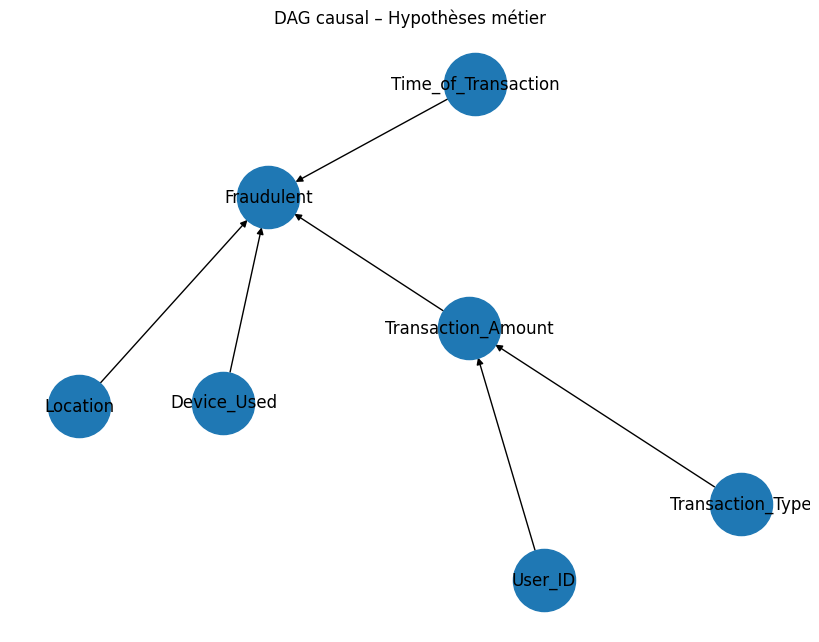

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

edges = [
    ("Transaction_Amount", "Fraudulent"),
    ("Time_of_Transaction", "Fraudulent"),
    ("Device_Used", "Fraudulent"),
    ("Location", "Fraudulent"),
    ("Transaction_Type", "Transaction_Amount"),
    ("User_ID", "Transaction_Amount"),
]

G.add_edges_from(edges)

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True, node_size=2000)
plt.title("DAG causal – Hypothèses métier")
plt.show()

In [22]:
#Interprétation DAG
dag_prompt = """
Tu es un expert senior en détection de fraude en assurance.

On considère le graphe causal (DAG) suivant représentant des hypothèses métier.

Variables :
- Transaction_Amount : montant de la transaction
- Time_of_Transaction : moment de la transaction
- Device_Used : type d’appareil utilisé
- Location : localisation de l’assuré
- Transaction_Type : type d’opération
- User_ID : identifiant client
- Fraudulent : indicateur de fraude (1 = fraude)

Relations causales supposées :
- Transaction_Amount → Fraudulent
- Time_of_Transaction → Fraudulent
- Device_Used → Fraudulent
- Location → Fraudulent
- Transaction_Type → Transaction_Amount
- User_ID → Transaction_Amount

Analyse ce DAG comme un expert métier.

Tâches :

1. Interpréter chaque relation causalement
2. Expliquer la logique fraude derrière ces liens
3. Identifier les drivers majeurs de fraude
4. Critiquer les relations discutables ou manquantes
5. Proposer des améliorations du DAG
"""

In [21]:
#Analyse métier
response = client.chat.completions.create(
    model="gpt-4.1",   # ou gpt-4o / gpt-5 si dispo
    messages=[
        {"role": "system", "content": "Tu es un expert en fraude assurance."},
        {"role": "user", "content": context_prompt + "\n\n" + dag_prompt}
    ],
    temperature=0.3
)

print(response.choices[0].message.content)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [23]:
#Génération de données synthétiques
gen_prompt = """
Génère 20 observations synthétiques FRAUDULENT = 1.

Contraintes :
- Données réalistes
- Cohérentes avec le graphe causal
- Format JSON (liste de dictionnaires)
"""

In [24]:
response_gen = client.chat.completions.create(
    model="gpt-4.1",
    messages=[
        {"role": "system", "content": "Tu es un expert en fraude assurance."},
        {"role": "user", "content": context_prompt + "\n\n" + gen_prompt}
    ],
    temperature=0.7
)

print(response_gen.choices[0].message.content)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}